In [144]:
import os

import torch
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import librosa.display
import numpy as np

from tqdm import tqdm
from TTS.tts.models.tacotron2 import Tacotron2
from TTS.tts.configs.tacotron2_config import Tacotron2Config
from TTS.utils.audio import AudioProcessor
from TTS.tts.utils.text.tokenizer import TTSTokenizer

from IPython.display import Audio

%matplotlib inline


In [145]:
model_path = r"C:\Users\ext-ananeva\phon_clust\gitlab\ssl_phoneme_clusterizer\TacotronProject\run-December-12-2025_08+16PM-586346f\best_model.pth"
config_path = r"C:\Users\ext-ananeva\phon_clust\gitlab\ssl_phoneme_clusterizer\TacotronProject\run-December-12-2025_08+16PM-586346f\config.json"
device = "cuda" if torch.cuda.is_available() else "cpu"

In [146]:
config = Tacotron2Config()
config.load_json(config_path)
tokenizer, config = TTSTokenizer.init_from_config(config)
ap = AudioProcessor(**config["audio"])

 > Setting up Audio Processor...
 | > sample_rate:16000
 | > resample:False
 | > num_mels:80
 | > log_func:np.log10
 | > min_level_db:-100
 | > frame_shift_ms:None
 | > frame_length_ms:None
 | > ref_level_db:20
 | > fft_size:1024
 | > power:1.5
 | > preemphasis:0.0
 | > griffin_lim_iters:60
 | > signal_norm:False
 | > symmetric_norm:True
 | > mel_fmin:0
 | > mel_fmax:8000.0
 | > pitch_fmin:1.0
 | > pitch_fmax:640.0
 | > spec_gain:1.0
 | > stft_pad_mode:reflect
 | > max_norm:4.0
 | > clip_norm:True
 | > do_trim_silence:True
 | > trim_db:45
 | > do_sound_norm:False
 | > do_amp_to_db_linear:True
 | > do_amp_to_db_mel:True
 | > do_rms_norm:False
 | > db_level:None
 | > stats_path:None
 | > base:10
 | > hop_length:256
 | > win_length:1024


In [147]:
model = Tacotron2.init_from_config(config)
model.load_checkpoint(config, model_path)
model.eval()

 > Setting up Audio Processor...
 | > sample_rate:16000
 | > resample:False
 | > num_mels:80
 | > log_func:np.log10
 | > min_level_db:-100
 | > frame_shift_ms:None
 | > frame_length_ms:None
 | > ref_level_db:20
 | > fft_size:1024
 | > power:1.5
 | > preemphasis:0.0
 | > griffin_lim_iters:60
 | > signal_norm:False
 | > symmetric_norm:True
 | > mel_fmin:0
 | > mel_fmax:8000.0
 | > pitch_fmin:1.0
 | > pitch_fmax:640.0
 | > spec_gain:1.0
 | > stft_pad_mode:reflect
 | > max_norm:4.0
 | > clip_norm:True
 | > do_trim_silence:True
 | > trim_db:45
 | > do_sound_norm:False
 | > do_amp_to_db_linear:True
 | > do_amp_to_db_mel:True
 | > do_rms_norm:False
 | > db_level:None
 | > stats_path:None
 | > base:10
 | > hop_length:256
 | > win_length:1024


Tacotron2(
  (embedding): Embedding(40, 512, padding_idx=0)
  (encoder): Encoder(
    (convolutions): ModuleList(
      (0): ConvBNBlock(
        (convolution1d): Conv1d(512, 512, kernel_size=(5,), stride=(1,), padding=(2,))
        (batch_normalization): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (dropout): Dropout(p=0.5, inplace=False)
        (activation): ReLU()
      )
      (1): ConvBNBlock(
        (convolution1d): Conv1d(512, 512, kernel_size=(5,), stride=(1,), padding=(2,))
        (batch_normalization): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (dropout): Dropout(p=0.5, inplace=False)
        (activation): ReLU()
      )
      (2): ConvBNBlock(
        (convolution1d): Conv1d(512, 512, kernel_size=(5,), stride=(1,), padding=(2,))
        (batch_normalization): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (dropout): Dropout(p=0.5, inplace=Fal

In [148]:
def show_result(text, original_text, id):
    print(text)
    inputs = tokenizer.text_to_ids(text)
    inputs = torch.LongTensor(inputs)[None, :]  # batch размером 1
    with torch.no_grad():
        outputs = model.inference(inputs)
        
        
    mel_post = outputs["model_outputs"].squeeze().cpu().numpy()  # основная мел-спектрограмма (postnet)
    alignments = outputs["alignments"].squeeze().cpu().numpy()   # ← attention map  
    
    mel_post = ap.denormalize(mel_post)  # ← возвращает в dB шкалу
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 5))
    
    # Mel postnet (финальная)
    axes[0].imshow(mel_post.T, aspect="auto", origin="lower", cmap="viridis")
    axes[0].set_title("Mel-Spectrogram")
    
    # Attention alignments
    axes[1].imshow(alignments, aspect="auto", origin="lower", cmap="viridis")
    axes[1].set_title("Alignments")
    plt.suptitle(f"{id}. {original_text[:200]}")
    plt.show()
    
    
    wav = ap.inv_melspectrogram(mel_post.T)
    
    wav_name = f"{id}.wav"
    ap.save_wav(wav, wav_name)
    return wav_name
    


In [154]:
original_texts = ["Он искал ее в Геленджике, в Гаграх, в Сочи.",
         "На другой день по приезде в Сочи,он купался утром в море, потом брился, надел чистое белье, белоснежный китель, позавтракал в своей гостинице на террасе ресторана, выпил бутылку шампанского, пил кофе с шартрезом, не спеша выкурил сигару.",
         "Возвратясь в свой номер, он лег на диван и выстрелил себе в виски из двух револьверов.",
         "Я ни перед чем не остановлюсь, защищая свою честь, честь мужа и офицера!",
         "А зачем все делается на свете?",
         " Разве мы понимаем что-нибудь в наших поступках?",
          "В анамнезе супермена был синтезированный компьютером криптонит.",
        "Мы всем отрядом съели все, что было во всем лагере, и все остались довольны.",
         "Бык тупогуб, тупогубенький бычок, У быка бела губа была тупа.",
         "В день Тлакашипеуалицтли жители Теночтитлана славят Шипе-Тотека, но не забывают также и про Уицилопочтли, Кецалькоатля и Тескатлипоку.",
         "Вот оно что. А он что? Да ты что!"]


# Преобразование осущствлялась в блокноте PreprocessTexts
texts = ["o0n i1ska0l ji1jo0 v g'i1l'i1nzhy0k'i4 , -- v ga0gra4h , -- f so0chi4 . ---",
     "na2 dru1go0j d'e0n' pa2 pr'i1je0z'd'i4 f so0chi4 , -- o0n ku1pa0ls'a4 u0tra4m vm mo0r'i4 , -- pa1to0m br'i0ls'a4 , -- na1d'e0l chi0sta4ji4 b'i1l'jo0 , -- b'i1la1s'n'e0zhny4j k'i0t'i4l' , -- pa1za0ftra4ka4l f sva1je0j ga2s't'i1n'i0cy4 na2 t'i1ra0s'i4 r'i1sta1ra0na4 , -- vy0p'i4l bu1ty0lku4 sha1mpa0nska4va4 , -- p'i0l ko0f'i4 s sha1rtr'e0za4m ,  n'i1 sp'i1sha0 vy0ku4r'i4l s'i1ga0ru4 .---- ",
     "va2zvra1t'a0s' v svo0j no0m'i4r , -- o0n l'o0k na2 d'i0va4n y1 vy0str'i4l'i4l s'i1b'e0 f v'i0sk'i4 y1z dvu0h r'i1vo0l'va4 . -----",
     "ja0 n'i1 p'i1r'i1d che0m n'i1 a1sta1no0vl'u4s' , --  za2sci1sca0ja4 sva1ju0 che0s't' , --  che0s't' mu0zha4 i1 a1f'i1ce0ra4 ! ---- ",
     "a1 za1che0m fs'o0 d'e0la4ji4ca4 na2 sv'e0t'i4 ? ---- ",
     "ra0zv'i4 my0 pa2n'i1ma0ji4m shto0 n'i1bu0t' v na0shy4h pa2stu1pka0h ? ---",
     "v a1na0mn'i4z' su1p'i1rm'e0na4 by0l s'i1n't'i1z'i1ra1va0jny4j ka1m'p'ju0t'i4ra4m kr'i1pto0n'i4t . ---",
     "my0 fs'o0m a1tr'a0da4m sje0l'i4 fs'o0 , -- shto0 by0la4 vo0 fs'o0m la1g'e0r'i4 , --  i1 fs'o0 a1sta0l'i4s' da1vo0l'ny4 . ----",
     "by0k tu1po0gu4p , --  tu1pa1gu0b'i4n'k'i4j by0cha4k , - u1 by1ka0 b'e0la4 gu1ba0 by1la0 tu1pa0 . ----",
     "ve0 d'e0n' tla1ka0shy4ji4s't'i4ca4 zhy1t'e0l'i4 -- t'i1na1chi0ta4la4 sla0v'a4t y1p'i0p' to0t'i4ka4 , --- no1 n'i1 za2by1va0ju4t ta1kzhe0 i1 pro0 u1h'i1cy1la1cha0chi4l , -- k'i1ca0l'ka4t'a4la4ja4 i1 t'i1ska0t'i4pa4ku4 . ---",
     'vo0t a1no0 shto0 . -- a1 o0n shto0 ? -- da1 ty0 shto0 ! ----']


o0n i1ska0l ji1jo0 v g'i1l'i1nzhy0k'i4 , -- v ga0gra4h , -- f so0chi4 . ---
   > Decoder stopped with `max_decoder_steps` 1000


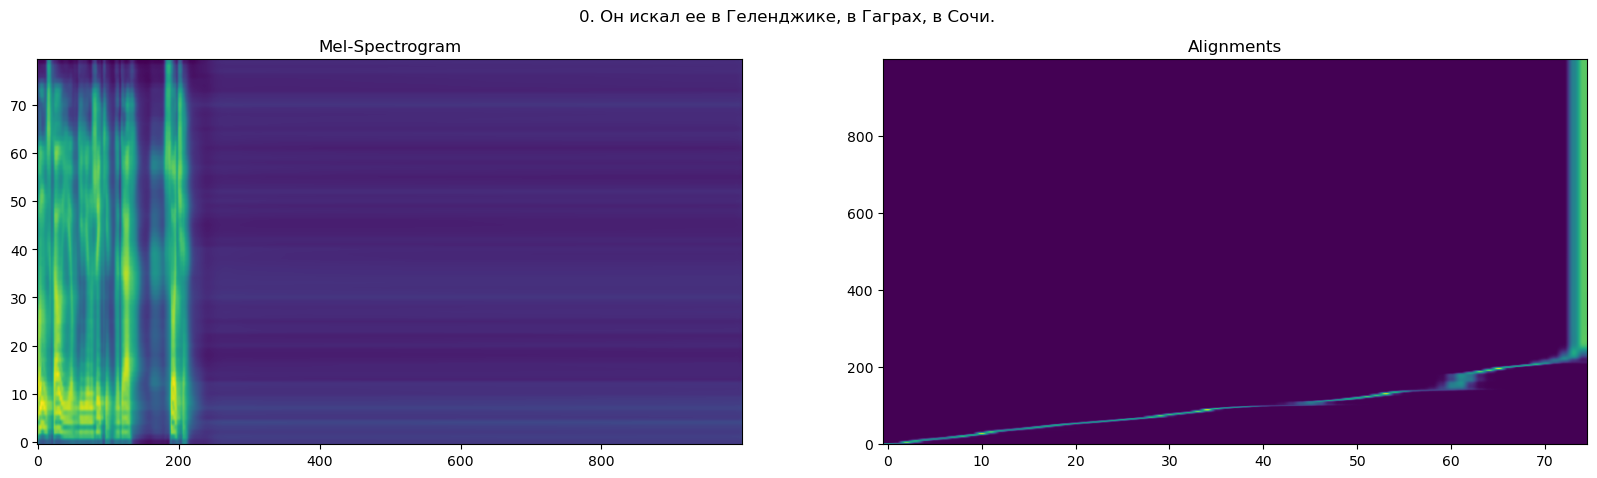

na2 dru1go0j d'e0n' pa2 pr'i1je0z'd'i4 f so0chi4 , -- o0n ku1pa0ls'a4 u0tra4m vm mo0r'i4 , -- pa1to0m br'i0ls'a4 , -- na1d'e0l chi0sta4ji4 b'i1l'jo0 , -- b'i1la1s'n'e0zhny4j k'i0t'i4l' , -- pa1za0ftra4ka4l f sva1je0j ga2s't'i1n'i0cy4 na2 t'i1ra0s'i4 r'i1sta1ra0na4 , -- vy0p'i4l bu1ty0lku4 sha1mpa0nska4va4 , -- p'i0l ko0f'i4 s sha1rtr'e0za4m ,  n'i1 sp'i1sha0 vy0ku4r'i4l s'i1ga0ru4 .---- 
   > Decoder stopped with `max_decoder_steps` 1000


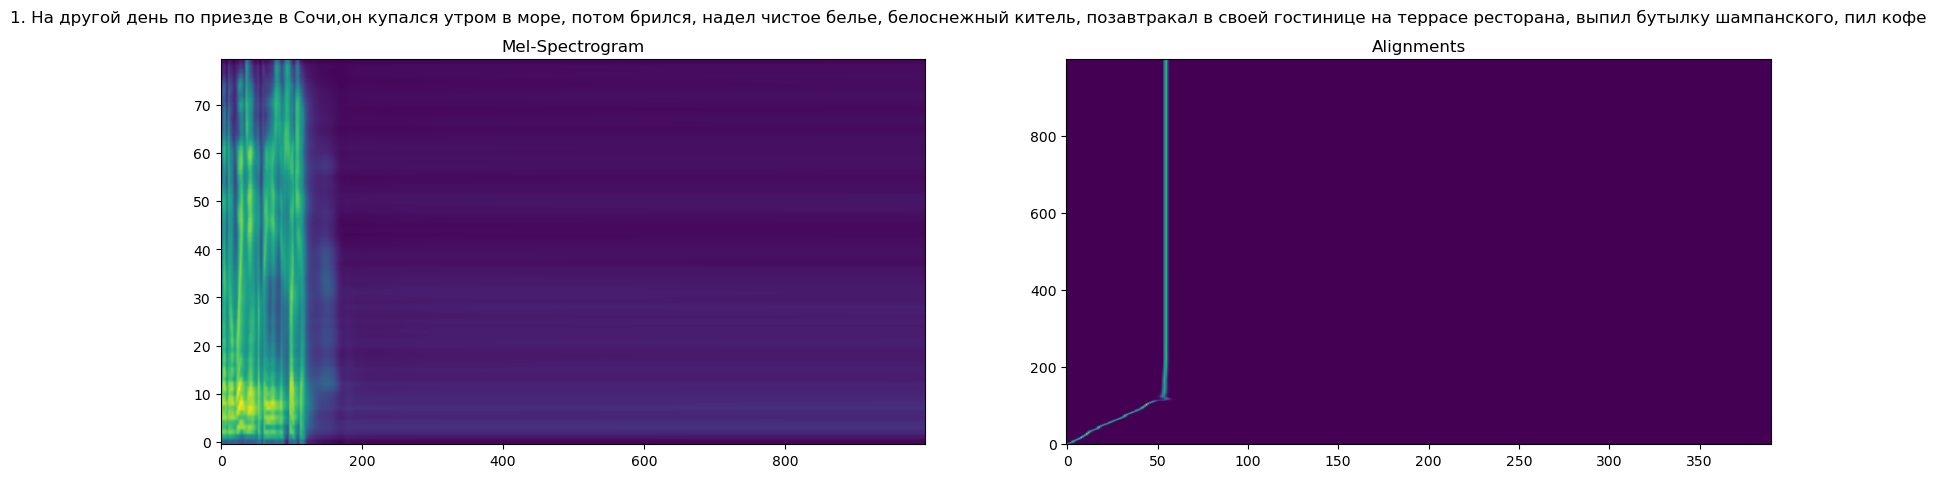

va2zvra1t'a0s' v svo0j no0m'i4r , -- o0n l'o0k na2 d'i0va4n y1 vy0str'i4l'i4l s'i1b'e0 f v'i0sk'i4 y1z dvu0h r'i1vo0l'va4 . -----
   > Decoder stopped with `max_decoder_steps` 1000


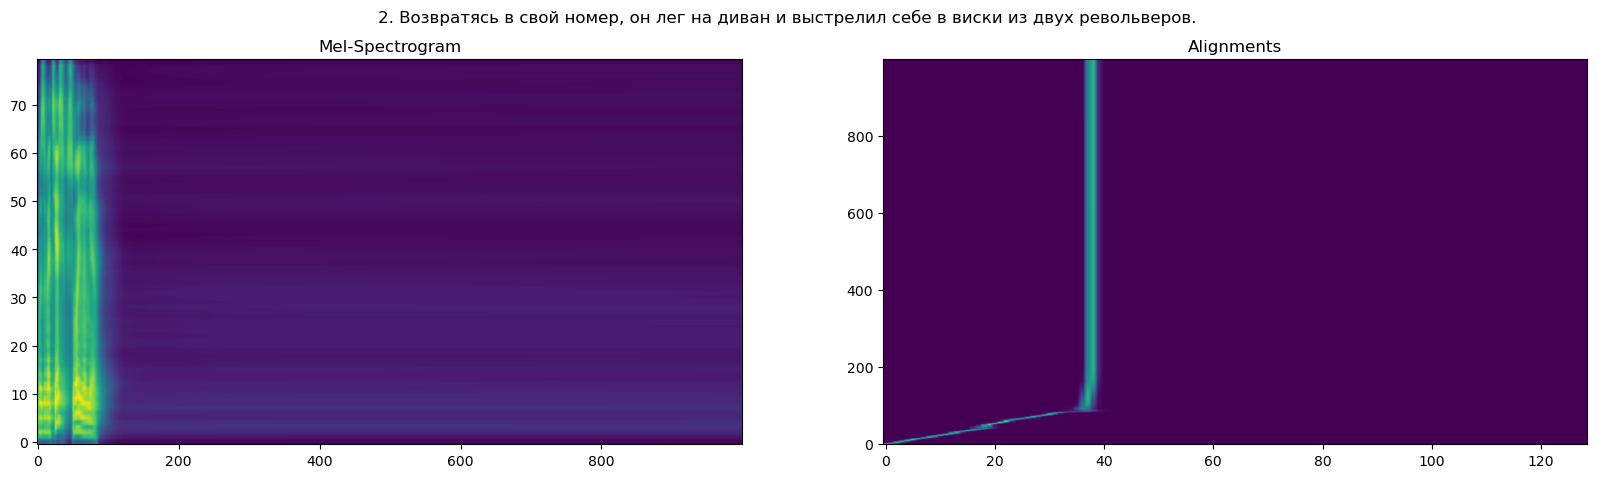

ja0 n'i1 p'i1r'i1d che0m n'i1 a1sta1no0vl'u4s' , --  za2sci1sca0ja4 sva1ju0 che0s't' , --  che0s't' mu0zha4 i1 a1f'i1ce0ra4 ! ---- 
   > Decoder stopped with `max_decoder_steps` 1000


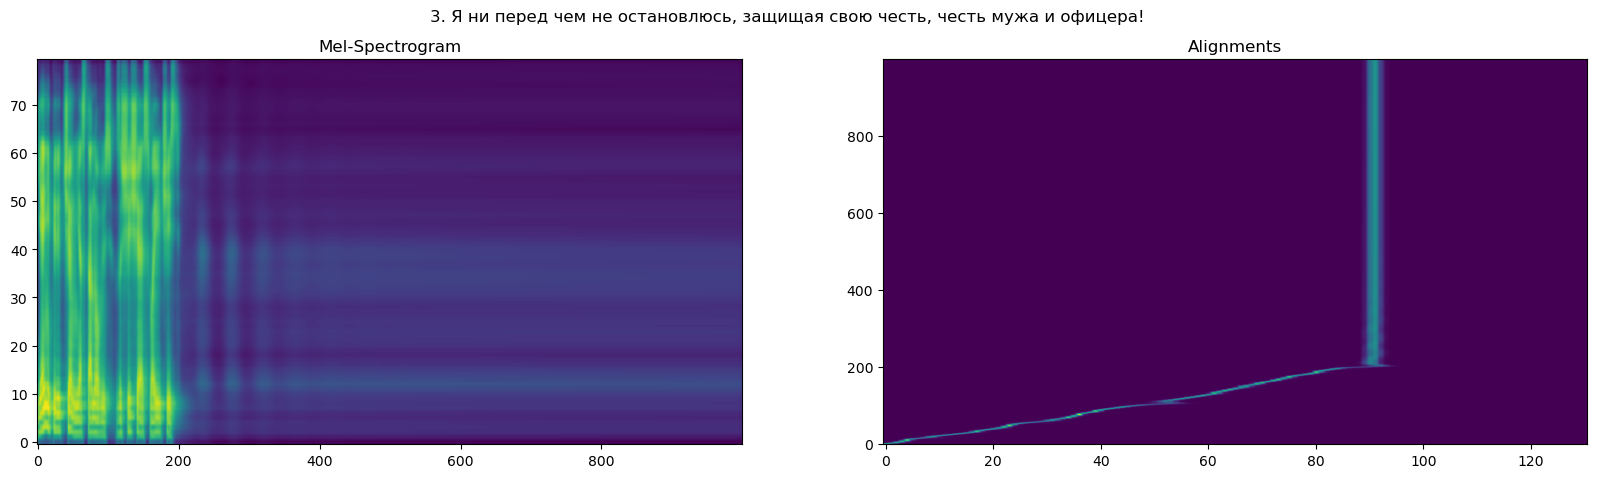

a1 za1che0m fs'o0 d'e0la4ji4ca4 na2 sv'e0t'i4 ? ---- 
   > Decoder stopped with `max_decoder_steps` 1000


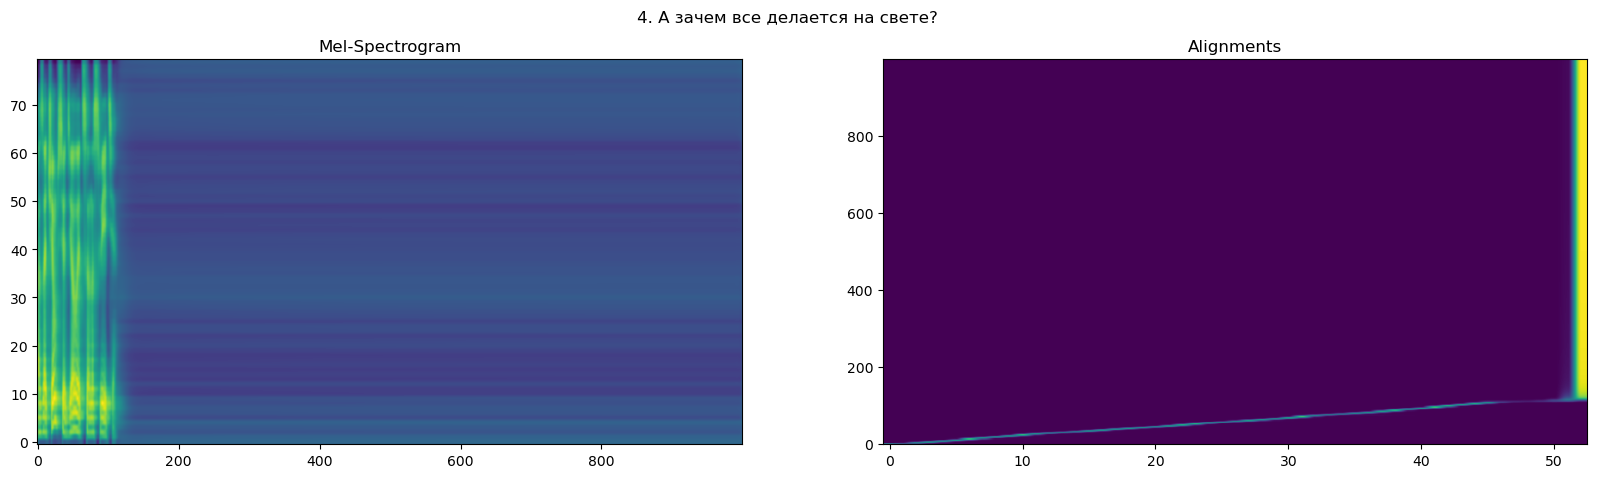

ra0zv'i4 my0 pa2n'i1ma0ji4m shto0 n'i1bu0t' v na0shy4h pa2stu1pka0h ? ---
   > Decoder stopped with `max_decoder_steps` 1000


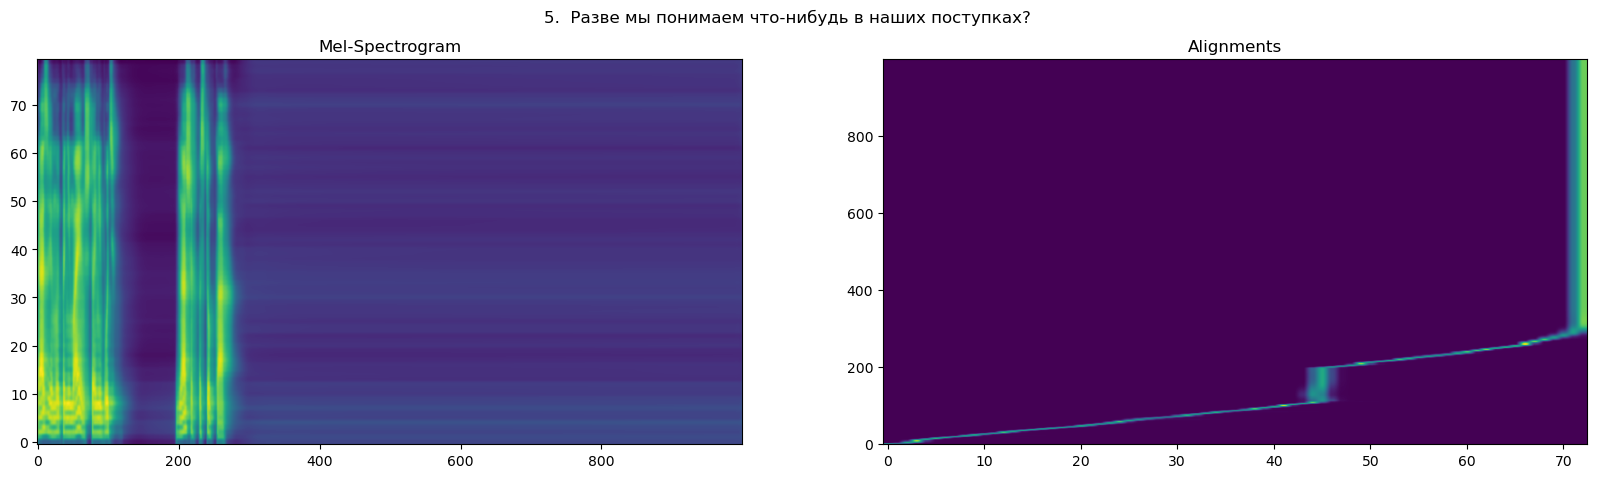

v a1na0mn'i4z' su1p'i1rm'e0na4 by0l s'i1n't'i1z'i1ra1va0jny4j ka1m'p'ju0t'i4ra4m kr'i1pto0n'i4t . ---
   > Decoder stopped with `max_decoder_steps` 1000


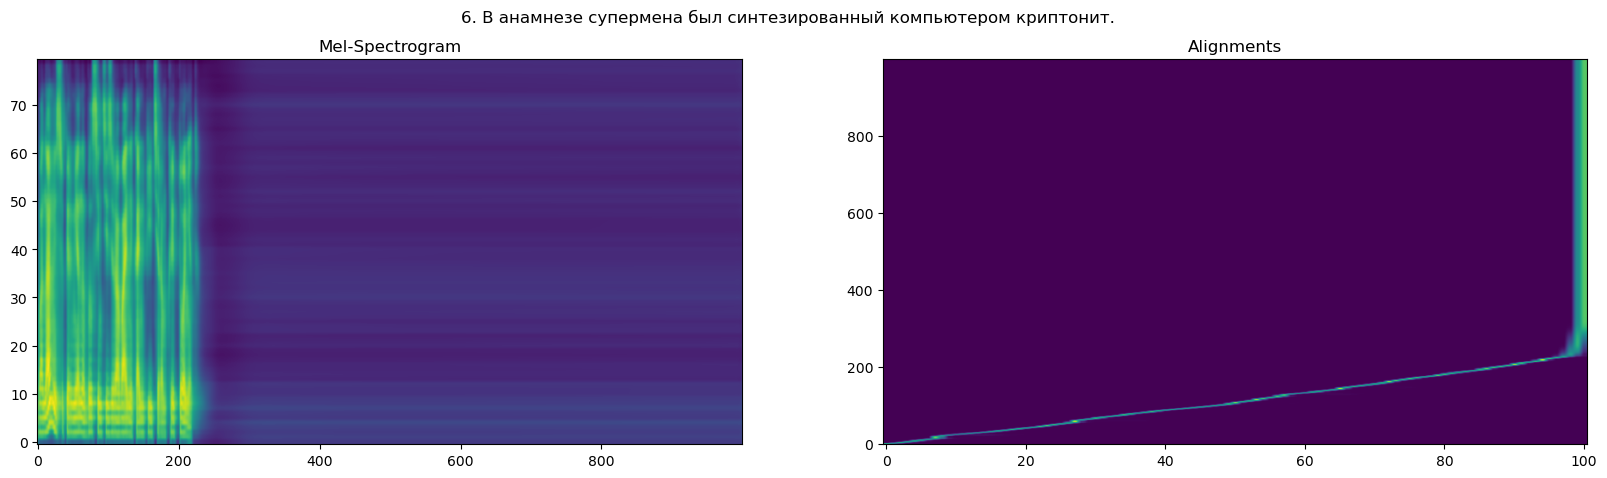

my0 fs'o0m a1tr'a0da4m sje0l'i4 fs'o0 , -- shto0 by0la4 vo0 fs'o0m la1g'e0r'i4 , --  i1 fs'o0 a1sta0l'i4s' da1vo0l'ny4 . ----
   > Decoder stopped with `max_decoder_steps` 1000


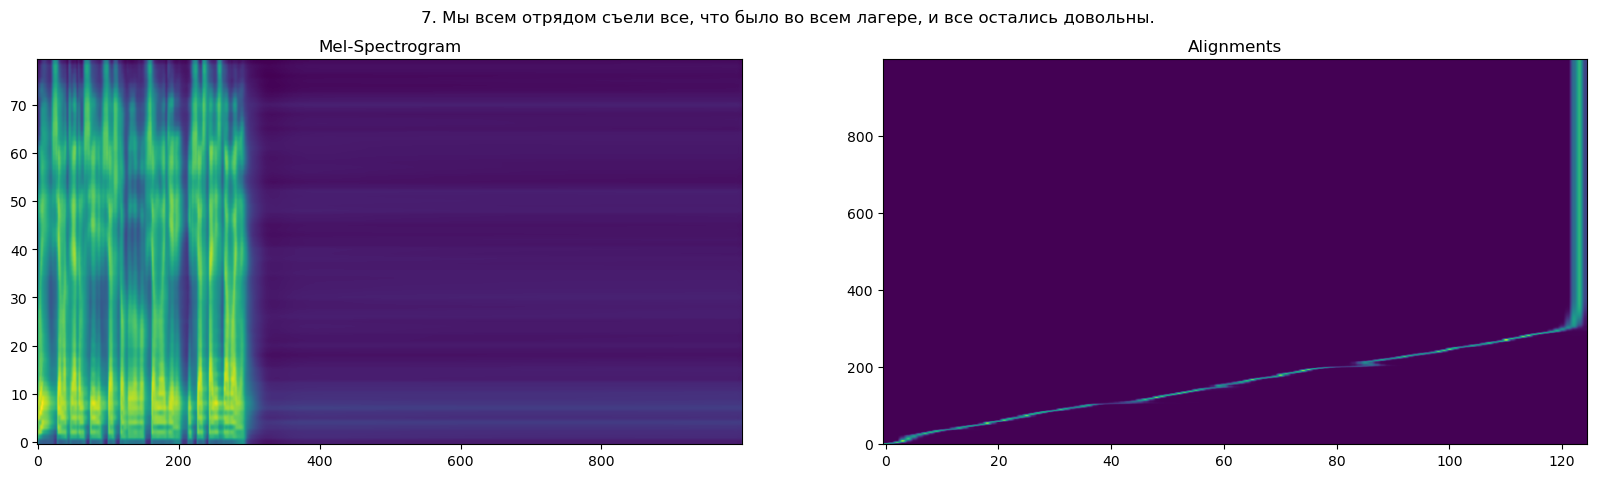

by0k tu1po0gu4p , --  tu1pa1gu0b'i4n'k'i4j by0cha4k , - u1 by1ka0 b'e0la4 gu1ba0 by1la0 tu1pa0 . ----
   > Decoder stopped with `max_decoder_steps` 1000


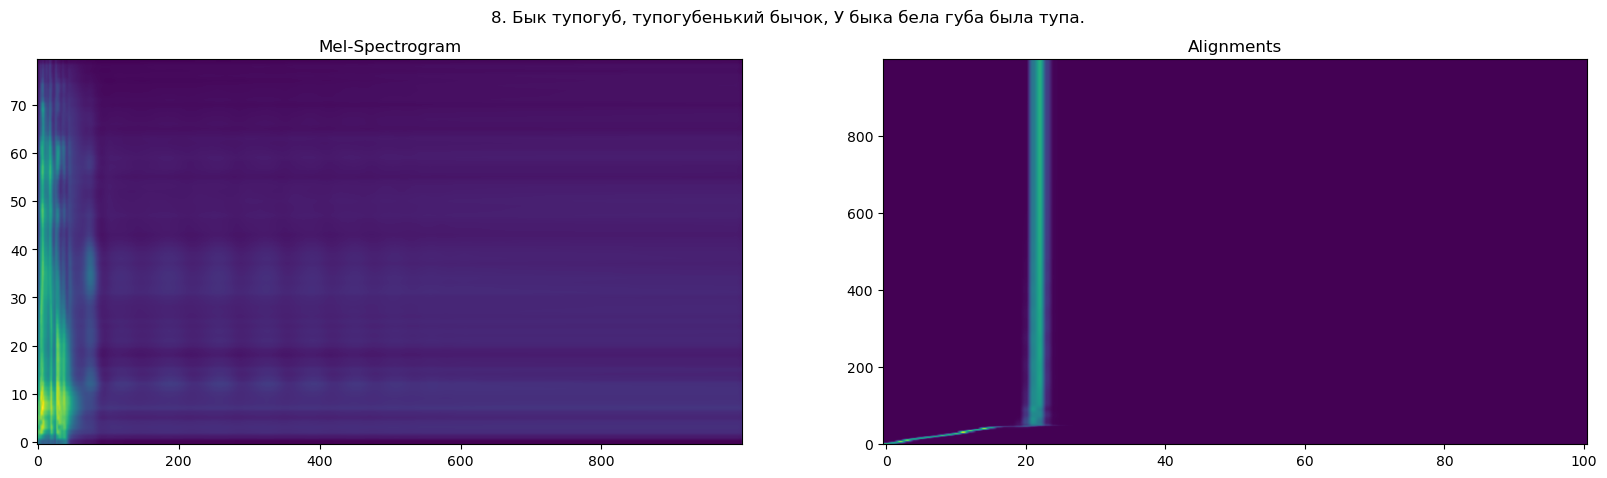

ve0 d'e0n' tla1ka0shy4ji4s't'i4ca4 zhy1t'e0l'i4 -- t'i1na1chi0ta4la4 sla0v'a4t y1p'i0p' to0t'i4ka4 , --- no1 n'i1 za2by1va0ju4t ta1kzhe0 i1 pro0 u1h'i1cy1la1cha0chi4l , -- k'i1ca0l'ka4t'a4la4ja4 i1 t'i1ska0t'i4pa4ku4 . ---
   > Decoder stopped with `max_decoder_steps` 1000


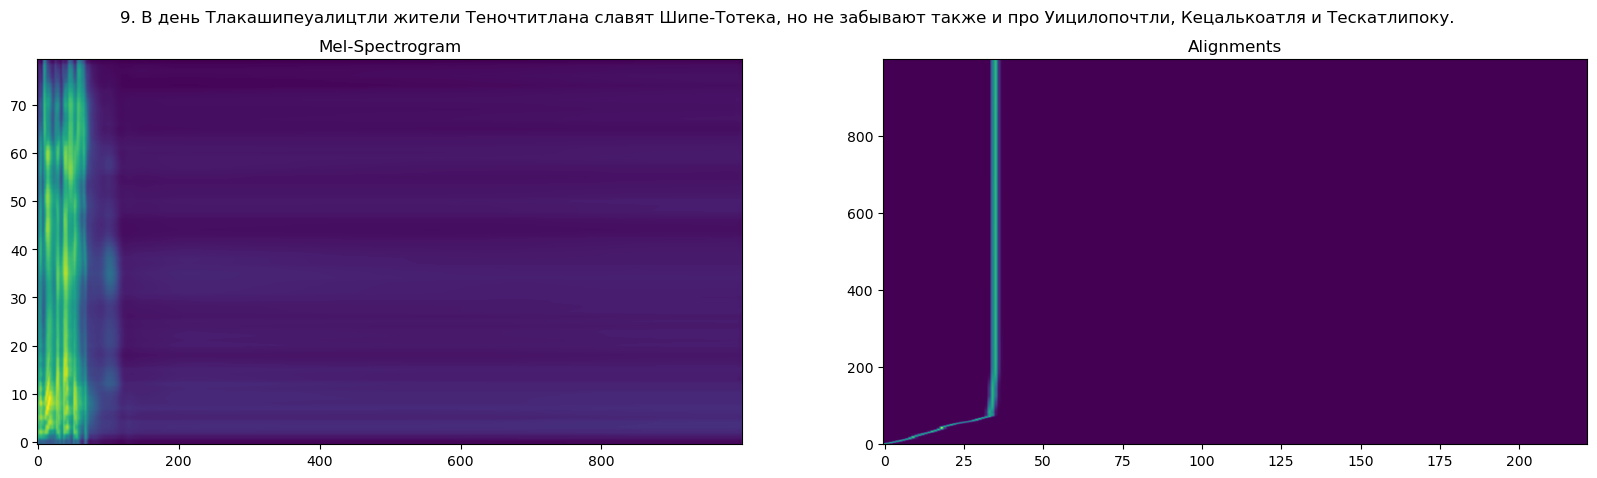

vo0t a1no0 shto0 . -- a1 o0n shto0 ? -- da1 ty0 shto0 ! ----
   > Decoder stopped with `max_decoder_steps` 1000


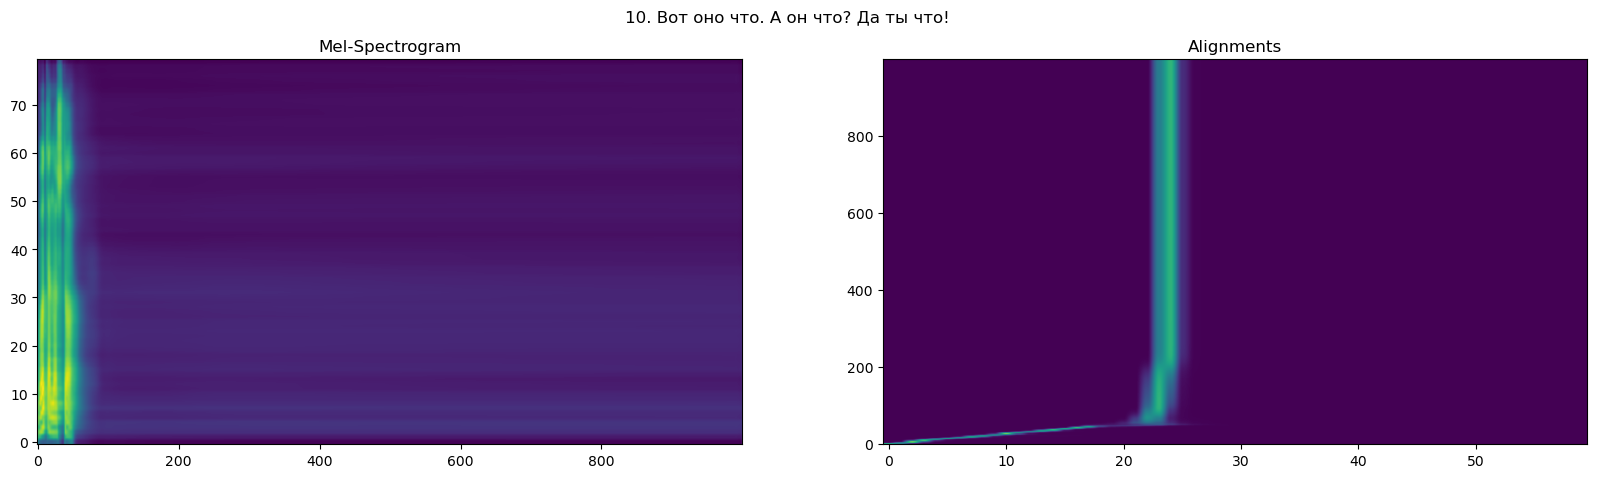

In [155]:
for i, text in enumerate(texts):
    show_result(text, original_texts[i], i)

16000 (255744,)


In [153]:
#checkpoint 70000
